In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\redes\Downloads\creditcard.csv")

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
print(f'Shape of the dataset: {df.shape}')  #number of rows and columns
print(f'Class Categories: {df.Class.unique()}')  #our categories
print(f'number of records of 0: {(df.Class == 0).sum()}')  #number of records with class 0
print(f'number of records of 1: {(df.Class==1).sum()}')  #number of records with class 1

Shape of the dataset: (284807, 31)
Class Categories: [0 1]
number of records of 0: 284315
number of records of 1: 492


<Axes: xlabel='Class', ylabel='count'>

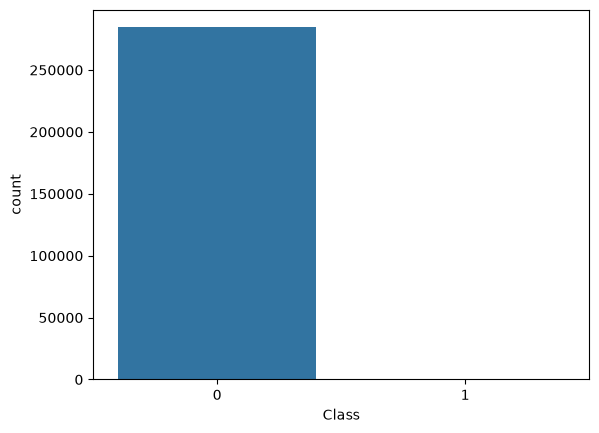

In [13]:
sns.countplot(x='Class', data=df)

In [15]:
x = df.corr()['Class'][:30]  
x

Time     -0.012323
V1       -0.101347
V2        0.091289
V3       -0.192961
V4        0.133447
V5       -0.094974
V6       -0.043643
V7       -0.187257
V8        0.019875
V9       -0.097733
V10      -0.216883
V11       0.154876
V12      -0.260593
V13      -0.004570
V14      -0.302544
V15      -0.004223
V16      -0.196539
V17      -0.326481
V18      -0.111485
V19       0.034783
V20       0.020090
V21       0.040413
V22       0.000805
V23      -0.002685
V24      -0.007221
V25       0.003308
V26       0.004455
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64

<Axes: title={'center': 'Correlation between features and Class'}>

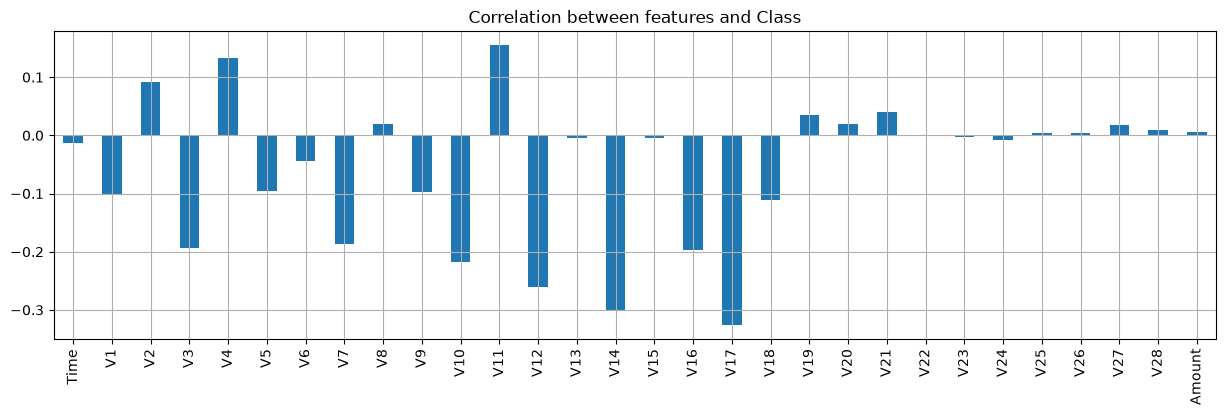

In [16]:
x.plot.bar(figsize=(15, 4), title="Correlation between features and Class", grid=True)

<Axes: >

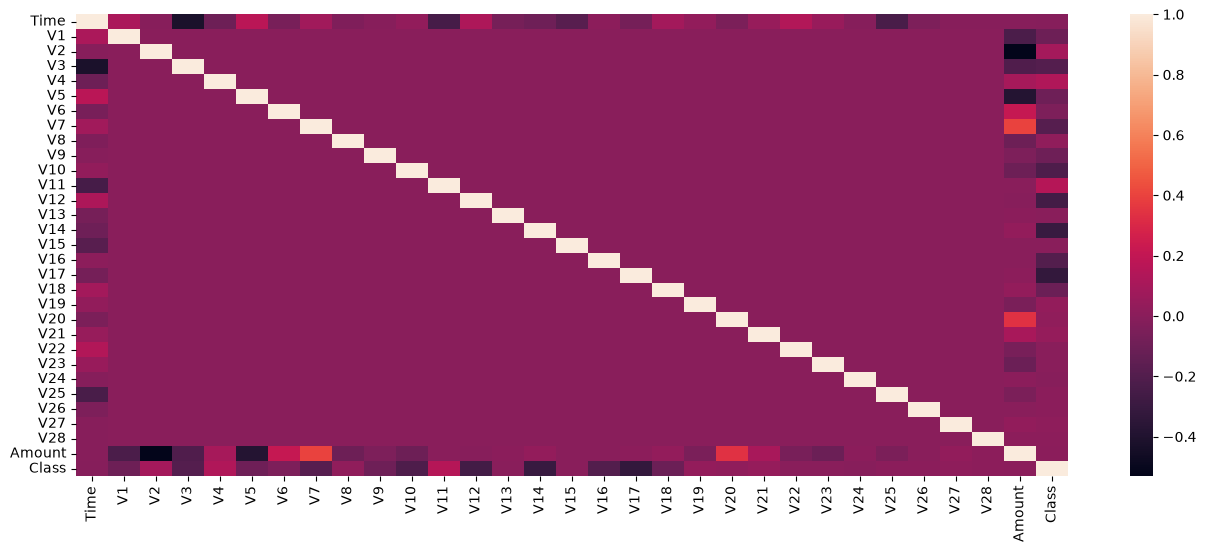

In [17]:
plt.figure(figsize=(16,6))
sns.heatmap(df.corr())

In [19]:
y = df.corr()['Class']

df2 = df.copy()

for i in df.columns:
  if abs(y[i]) < 0.13:
    df2.drop(columns=[i], inplace=True)  #removing less correlated features

In [20]:
df2.head()

,V3,V4,V7,V10,V11,V12,V14,V16,V17,Class
0,2.536347,1.378155,0.239599,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0
1,0.166480,0.448154,-0.078803,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,0
2,1.773209,0.379780,0.791461,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,0
3,1.792993,-0.863291,0.237609,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,0
4,1.548718,0.403034,0.592941,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,0


<Axes: >

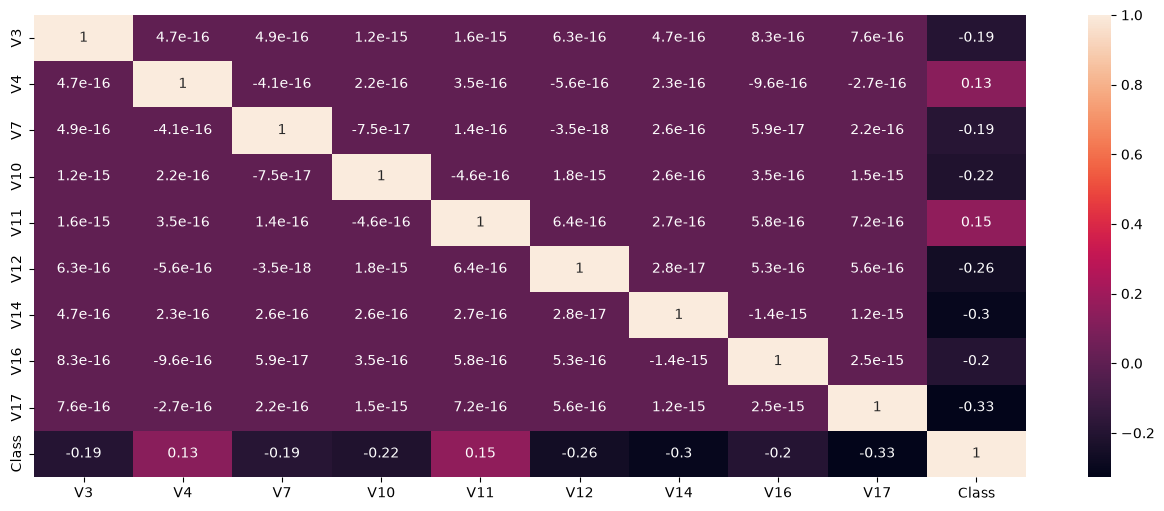

In [21]:
plt.figure(figsize=(16,6))
sns.heatmap(df2.corr(), annot=True)

<Axes: title={'center': 'Top Correlated Features With Target Variable'}>

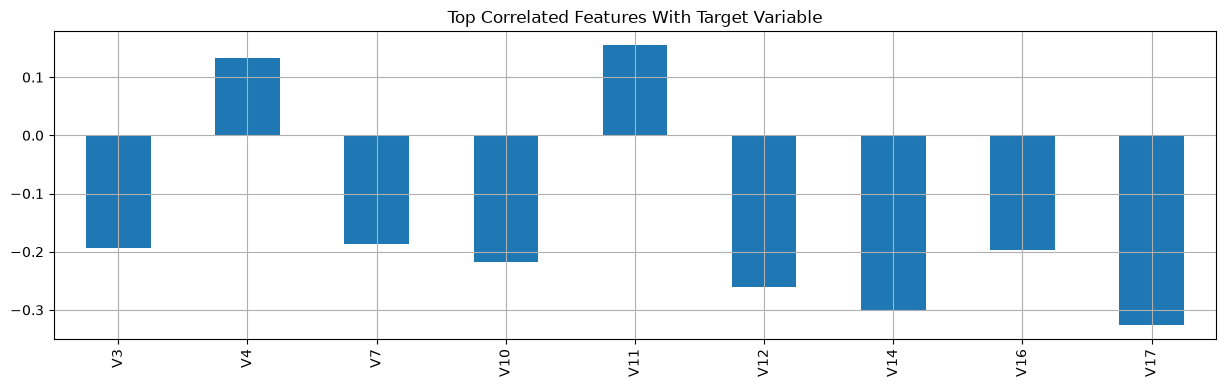

In [22]:
x = df2.corr()['Class'][:9]

x.plot.bar(figsize=(15,4), title="Top Correlated Features With Target Variable", grid=True)

In [25]:
pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from imblearn.under_sampling import RandomUnderSampler

X = df2.drop('Class', axis=1)
y = df2['Class']

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

downsampled_df = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Class'])], axis=1)

In [27]:
downsampled_df.shape

(984, 10)

<Axes: xlabel='Class', ylabel='count'>

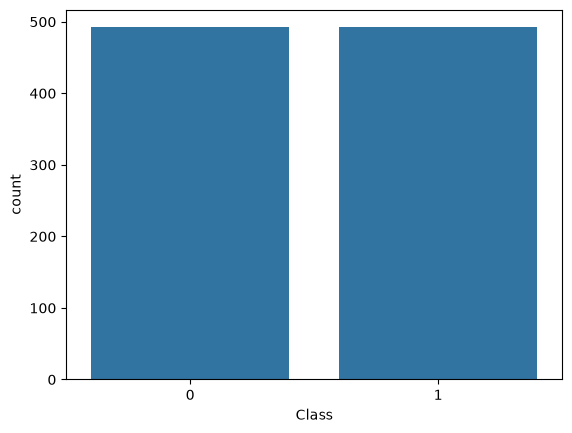

In [28]:
sns.countplot(x='Class', data=downsampled_df)

<Axes: xlabel='V11', ylabel='V17'>

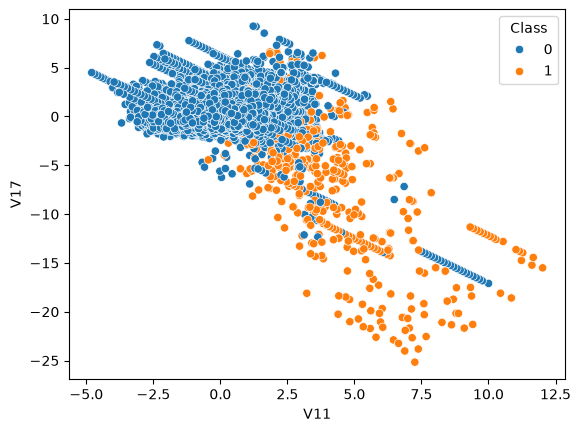

In [29]:
sns.scatterplot(x='V11', y='V17', hue='Class', data=df2)

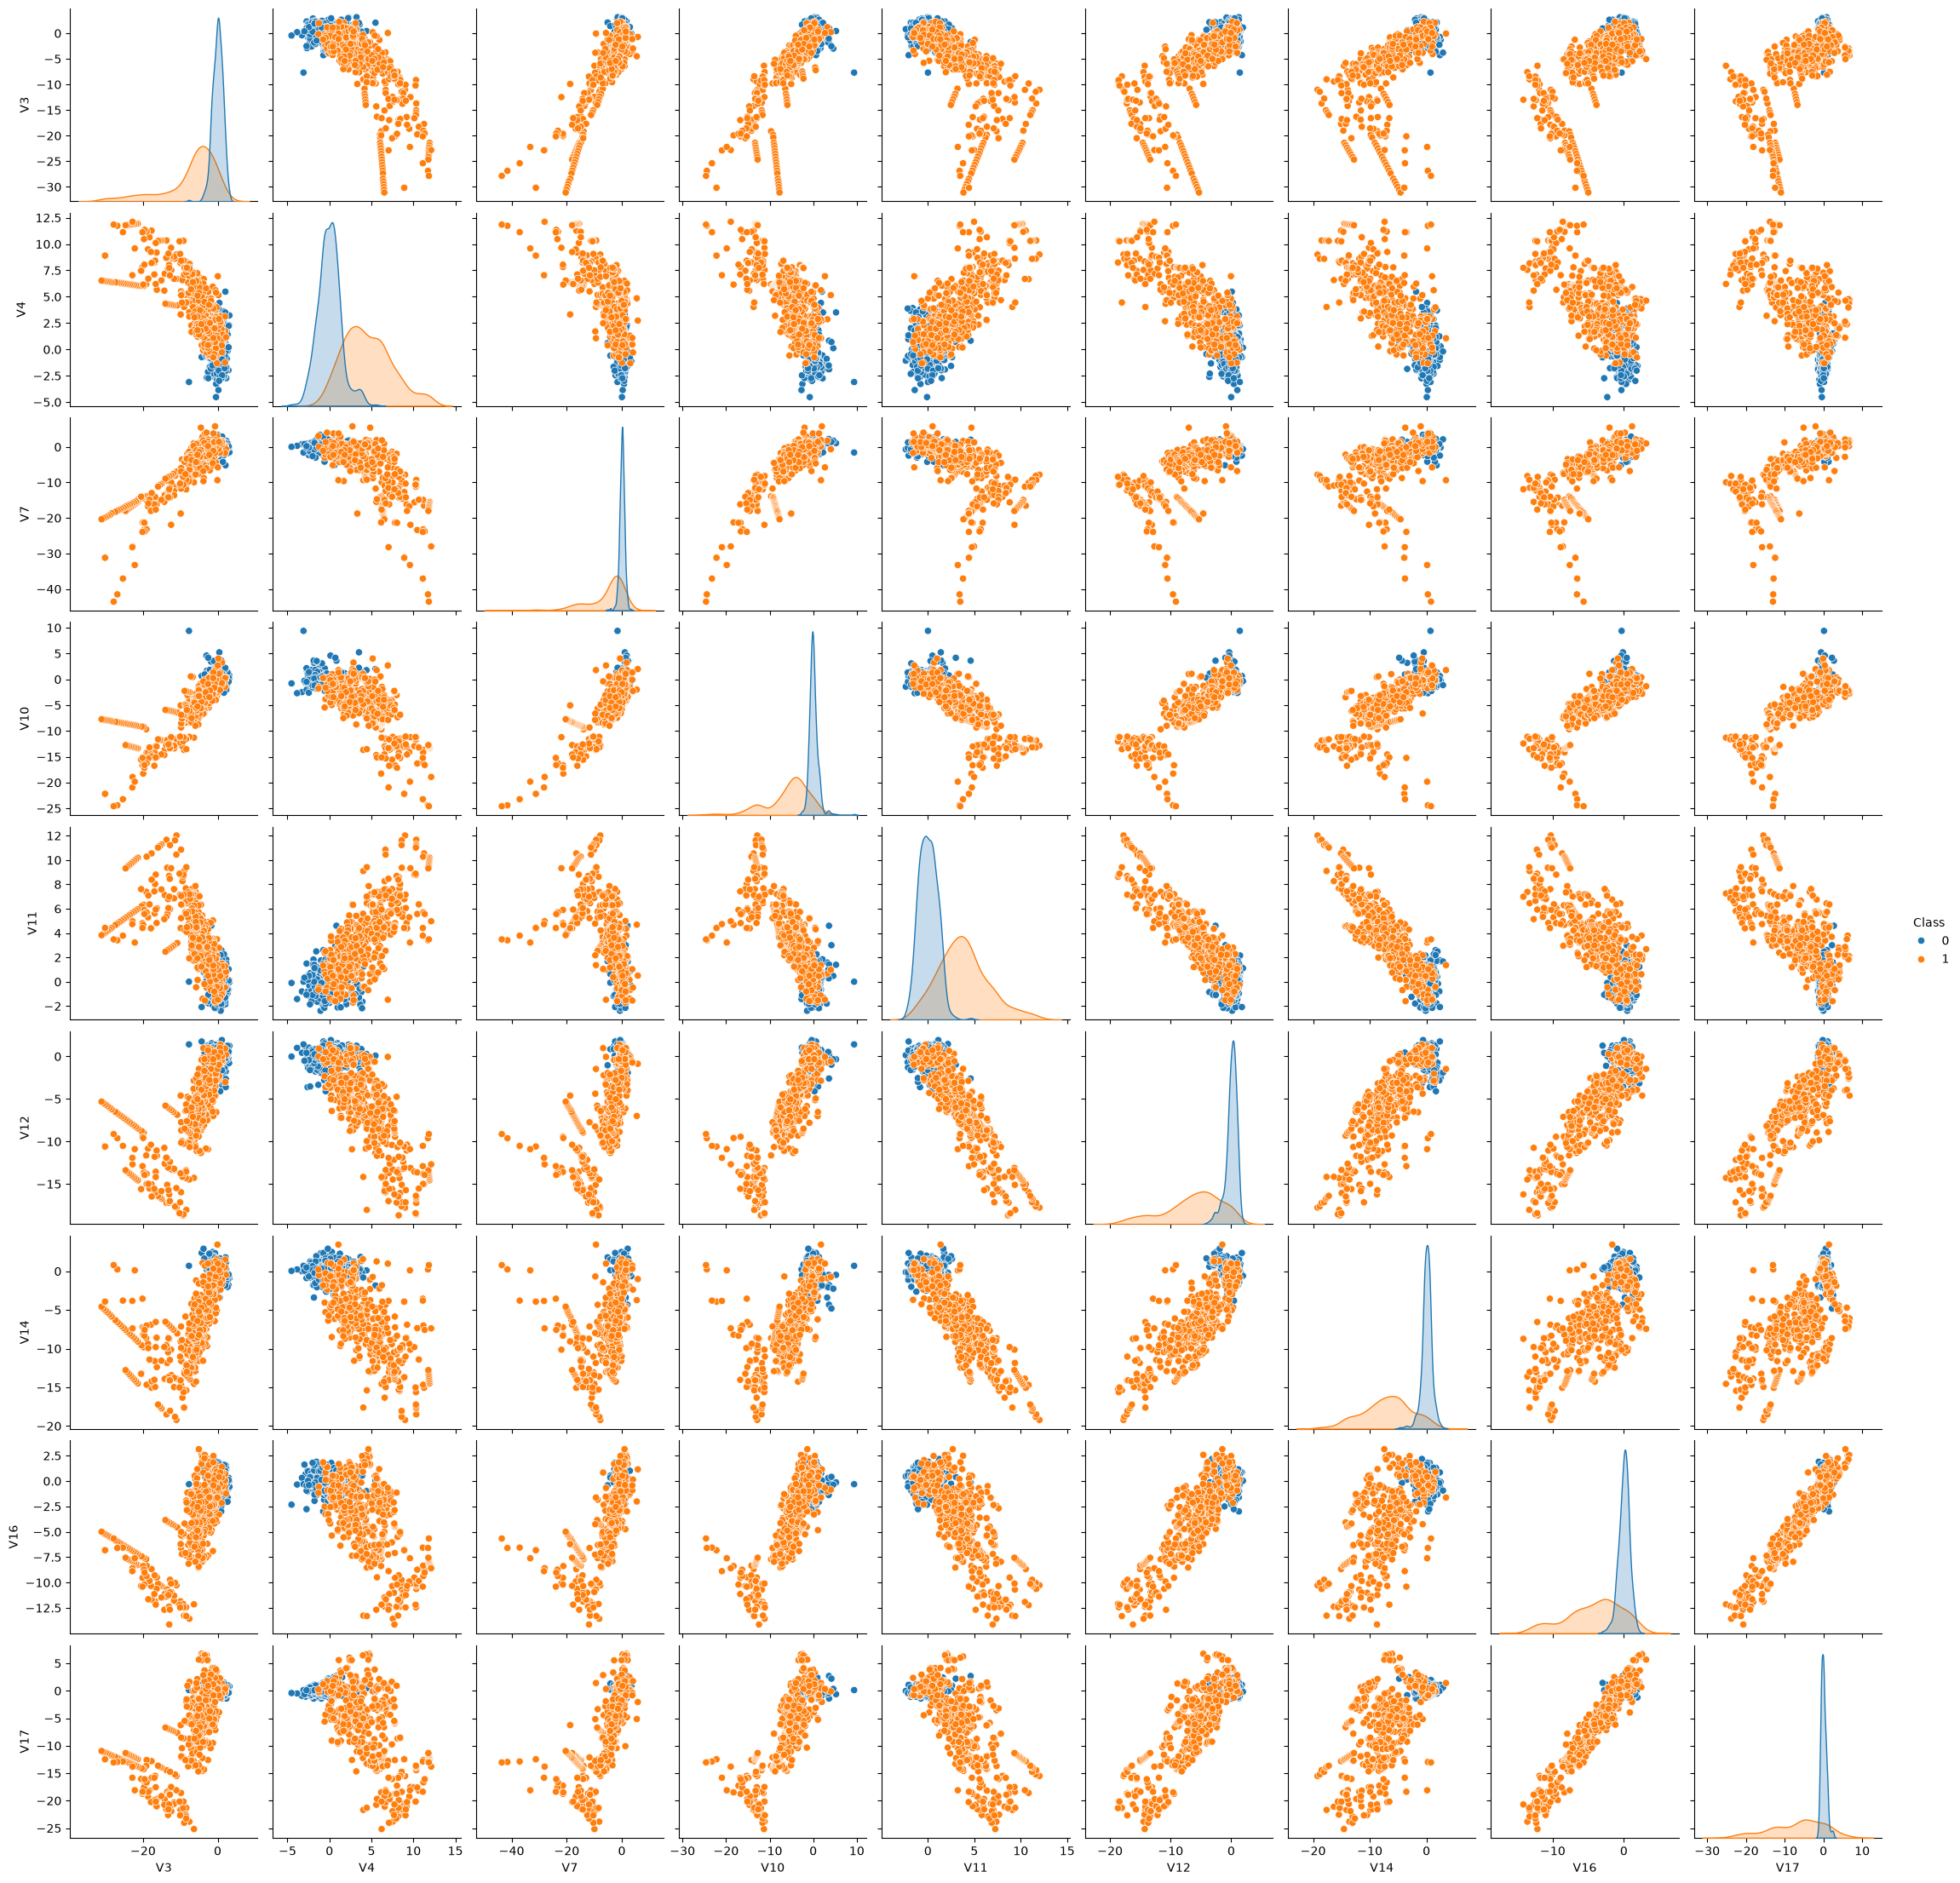

In [30]:
import warnings
warnings.filterwarnings('ignore')

sns.pairplot(downsampled_df, hue='Class')

In [32]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


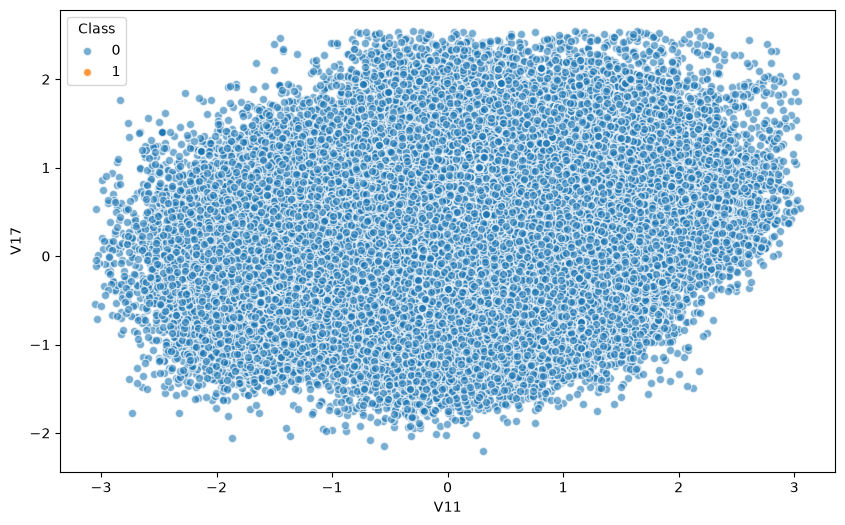

In [36]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

numerical_columns = df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(df[numerical_columns]))
threshold = 3
filtered_entries = (z_scores < threshold).all(axis=1)

df_cleaned = df[filtered_entries]

plt.figure(figsize=(10, 6))

class_0 = df_cleaned[df_cleaned['Class'] == 0]
plt.scatter(class_0['V11'], class_0['V17'], label='0', edgecolor='White', alpha=0.6)

# Class 1 Scatter
class_1 = df_cleaned[df_cleaned['Class'] == 1]
plt.scatter(class_1['V11'], class_1['V17'], label='1', edgecolor='White', alpha=0.8)

# Labels and Legend
plt.xlabel('V11')
plt.ylabel('V17')
plt.legend(title='Class')
plt.show()


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
X = df2.drop(columns='Class')
y = df2['Class']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_data = X_train_orig.copy()
train_data['Class'] = y_train_orig

majority_class = train_data[train_data['Class'] == 0]
minority_class = train_data[train_data['Class'] == 1]

majority_downsampled = resample(majority_class,
                                replace=False,
                                n_samples=len(minority_class),
                                random_state=42)
downsampled_data = pd.concat([majority_downsampled, minority_class])

X_train_downsampled = downsampled_data.drop(columns='Class')
y_train_downsampled = downsampled_data['Class']

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9990871107053826
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.57      0.68        98

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [40]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9992802219023208
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.68      0.77        98

    accuracy                           1.00     56962
   macro avg       0.93      0.84      0.88     56962
weighted avg       1.00      1.00      1.00     56962

